# Exercise 1: Digit Classification with Logistic Regression

In this notebook we will use simple logistic regression to see how far we can get when classifying images with digits on it. For this we use the famous MNIST dataset.

### 1. Data Loading and Analysis

We work with the MNIST dataset which is a large database of handwritten digits and very popular for testing machine learning models. You can find more details about the dataset [here](https://en.wikipedia.org/wiki/MNIST_database).

We download the dataset directly via the sklearn library. This may take a short while ... 

In [1]:
from sklearn.datasets import fetch_openml
x, y = fetch_openml('mnist_784', version=1, return_X_y=True, data_home="./data")

Next, we have a brief look at the data:

In [2]:
print("X is a", type(x))
print("y is a", type(y))

X is a <class 'pandas.DataFrame'>
y is a <class 'pandas.Series'>


In [3]:
x.shape

(70000, 784)

In [4]:
x.head(3)

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


One data point consists of 784 pixel values (=28x28 pixels) that represent an image showing a handwritten digit.
Let's look at the data for one data point:

In [5]:
x.iloc[0].describe()

count    784.000000
mean      35.108418
std       79.699674
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      255.000000
Name: 0, dtype: float64

The pixels of one datapoint have values between 0 and 255 which correspond to the grey value of that pixel. A value of zero means that the pixel is black, a value of 255 corresponds to a white pixel, every other value is some grey value in between.

The labels of the data are the digits that are actually shown on the image:

In [6]:
y.head(3)

0    5
1    0
2    4
Name: class, dtype: category
Categories (10, str): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [7]:
type(y.iloc[0])

str

Since the label is of type string, we convert it to an integer:

In [8]:
y = y.astype("int")

To get an impression how the pictures of the digits look like, we visualize the first three rows with matplotlib. For this, we need to reshape each row to dimension 28x28 and then plot it.

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

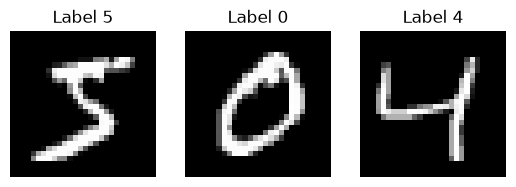

In [9]:
import numpy as np
import matplotlib.pyplot as plt

digit = x.iloc[0]
digit_pixels = np.array(digit).reshape(28, 28)
plt.subplot(131)
plt.title("Label " + str(y.iloc[0]))
plt.imshow(digit_pixels, cmap=plt.cm.gray)
plt.axis('off')

digit = x.iloc[1]
digit_pixels = np.array(digit).reshape(28, 28)
plt.subplot(132)
plt.title("Label " + str(y.iloc[1]))
plt.imshow(digit_pixels, cmap=plt.cm.gray)
plt.axis('off')

digit = x.iloc[2]
digit_pixels = np.array(digit).reshape(28, 28)
plt.subplot(133)
plt.title("Label " + str(y.iloc[2]))
plt.imshow(digit_pixels, cmap=plt.cm.gray)
plt.axis('off')

Before we start with the model training we divide it into train and test data.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

print("Train data points:", len(X_train))
print("Test data points:", len(X_test))

Train data points: 56000
Test data points: 14000


### 2. Model Training

Your exercise is now to train a logistic regression model using an one-vs-rest approach (see lecture slides).

For this, implement the following steps:
1. Apply min-max normalization to `X_train` and `X_test` to normalize the data.
2. Train a binary logistic regression to predict: "Is there the digit `9` on the image ?". Hint: For this you need to change the labels in `y_train`. Calculate the accuaracy of this classifer on the test data (you need to change also the labels in `y_test`).
3. Train a binary logistic regression on each digit from `0` to `9`. Save each model in a list.
4. For every test data point, predict which each model on it to find out which models returns the highest probability for the point. Hint: Use `.predict_proba()` to get class probabilities from each binary classifier.
5. Use the results from step 4 to calculate the accuracy of the overall approach on the test data. A correct implementation should achieve approximately 90% accuracy on test data.
7. Use `GridSearchCV` to tune the regularization parameter `C` (try values like 0.1, 1.0, 10.0) with 5-fold cross-validation.

---
## Solution

### Step 1: Min-Max Normalization

Min-max normalization rescales every feature (here: every pixel column) into the interval $[0, 1]$:

$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$

**Why do we need this?** Logistic regression is trained with gradient-based optimizers. If the features are in the range 0–255, the optimizer converges slowly (or not at all within the iteration limit) and the regularization term affects the weights unevenly. Scaled features make training faster and more stable.

**Important:** The scaler must be fitted **only on the training data** (`fit_transform`) and then applied to the test data with the *same* min/max values (`transform`). If we fitted it on the test data as well, information from the test set would leak into training (*data leakage*) and our test accuracy would be too optimistic.

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# learn min and max of every pixel from the training data and scale it
X_train_scaled = scaler.fit_transform(X_train)

# apply the SAME scaling (training min/max) to the test data
X_test_scaled = scaler.transform(X_test)

print("Train range: [{:.1f}, {:.1f}]".format(X_train_scaled.min(), X_train_scaled.max()))
print("Test range:  [{:.1f}, {:.1f}]".format(X_test_scaled.min(), X_test_scaled.max()))

Train range: [0.0, 1.0]
Test range:  [0.0, 64.0]


Note: Some pixels at the border of the image are 0 in *every* training image (min = max = 0). `MinMaxScaler` handles this case automatically and avoids a division by zero (these columns simply stay 0).

Test values can in principle land slightly outside $[0, 1]$, if a test pixel is brighter than the brightest training pixel in that position. That is expected and not a problem.

#### 💡 Nifty alternative
Since we *know* that grey values are always between 0 and 255, we can just divide by 255. That is the same idea (min-max scaling with the theoretical min 0 and max 255 for every pixel) and needs no fitting at all:

In [12]:
X_train_alt = X_train.to_numpy() / 255.0
X_test_alt = X_test.to_numpy() / 255.0

### Step 2: Binary classifier – "Is there a 9 on the image?"

Logistic regression is a **binary** classifier: it models the probability

$$P(y = 1 \mid x) = \sigma(w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}$$

So first we turn the 10-class problem into a yes/no problem: every label that is `9` becomes `1` (positive class), every other digit becomes `0` (negative class).

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# new binary labels: 1 if the digit is a 9, otherwise 0
y_train_9 = (y_train == 9).astype(int)
y_test_9 = (y_test == 9).astype(int)

print("Share of 9s in the training data: {:.1%}".format(y_train_9.mean()))

Share of 9s in the training data: 10.0%


In [14]:
# max_iter is increased because the default (100) is often not enough to converge on MNIST
model_9 = LogisticRegression(max_iter=1000)
model_9.fit(X_train_scaled, y_train_9)

y_pred_9 = model_9.predict(X_test_scaled)
acc_9 = accuracy_score(y_test_9, y_pred_9)
print("Accuracy of the '9 vs. rest' classifier on the test data: {:.2%}".format(acc_9))

Accuracy of the '9 vs. rest' classifier on the test data: 96.54%


**Interpretation – careful with accuracy here!** Only about 10% of the images show a 9. A "dumb" classifier that *always* answers "no 9" would already be about 90% correct. So the accuracy has to be compared against this baseline:

In [15]:
baseline = 1 - y_test_9.mean()   # accuracy of always predicting "not a 9"
print("Baseline (always predict 0): {:.2%}".format(baseline))
print("Our model:                   {:.2%}".format(acc_9))

Baseline (always predict 0): 90.28%
Our model:                   96.54%


Our model is clearly better than the baseline. For imbalanced binary problems, metrics like precision, recall or F1-score are often more meaningful than accuracy:

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test_9, y_pred_9, target_names=["not 9", "9"]))

              precision    recall  f1-score   support

       not 9       0.98      0.98      0.98     12639
           9       0.85      0.78      0.81      1361

    accuracy                           0.97     14000
   macro avg       0.91      0.88      0.90     14000
weighted avg       0.96      0.97      0.96     14000



### Step 3: One binary classifier per digit (One-vs-Rest)

**One-vs-Rest (OvR)** idea: For $K = 10$ classes we train $K$ binary classifiers. Classifier $k$ learns to distinguish "digit $k$" (label 1) from "all other digits" (label 0). This is exactly what we did in Step 2 for the 9 – now we do it in a loop for every digit and store the models in a list, so that `models[d]` is the classifier for digit `d`.

*(This cell trains 10 models on 56,000 images and may take a few minutes.)*

In [17]:
models = []

for digit in range(10):
    # binary labels for the current digit
    y_train_binary = (y_train == digit).astype(int)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_scaled, y_train_binary)
    models.append(model)

    print("Model for digit", digit, "trained")

print("\nNumber of models:", len(models))

Model for digit 0 trained
Model for digit 1 trained
Model for digit 2 trained
Model for digit 3 trained
Model for digit 4 trained
Model for digit 5 trained
Model for digit 6 trained
Model for digit 7 trained
Model for digit 8 trained
Model for digit 9 trained

Number of models: 10


### Step 4: Predict with all models – the highest probability wins

Every binary model returns via `.predict_proba()` an array with two columns:
- column 0: $P(\text{not digit } k \mid x)$
- column 1: $P(\text{digit } k \mid x)$

We only need **column 1**. For every test image we collect these 10 probabilities and choose the digit whose model is "most confident":

$$\hat{y} = \arg\max_{k \in \{0, ..., 9\}} P_k(y = 1 \mid x)$$

First, let's look at a single test image to understand what happens:

In [18]:
i = 0  # index of a test data point
single_image = X_test_scaled[i].reshape(1, -1)   # sklearn expects a 2D array

for digit, model in enumerate(models):
    p = model.predict_proba(single_image)[0, 1]
    print("P(digit = {}) = {:.4f}".format(digit, p))

print("\nTrue label:", y_test.iloc[i])

P(digit = 0) = 0.9973
P(digit = 1) = 0.0000
P(digit = 2) = 0.0001
P(digit = 3) = 0.0000
P(digit = 4) = 0.0005
P(digit = 5) = 0.0044
P(digit = 6) = 0.3248
P(digit = 7) = 0.0000
P(digit = 8) = 0.5282
P(digit = 9) = 0.0000

True label: 0


Note that the 10 probabilities do **not** add up to 1: each model was trained independently and only answers its own yes/no question. For the decision we only need the largest one.

Now we do this for **all** test data points at once. We build a matrix `probabilities` with shape `(14000, 10)`: row = test image, column = digit. `predict_proba` can process all test images in one call, so we only need to loop over the 10 models (much faster than looping over 14,000 images).

In [19]:
n_test = X_test_scaled.shape[0]
probabilities = np.zeros((n_test, 10))

for digit, model in enumerate(models):
    # column 1 = probability for "this is the digit"
    probabilities[:, digit] = model.predict_proba(X_test_scaled)[:, 1]

# for every row: index (= digit) of the highest probability
y_pred = np.argmax(probabilities, axis=1)

print("Shape of probability matrix:", probabilities.shape)
print("First 10 predictions:", y_pred[:10])
print("First 10 true labels:", y_test.values[:10])

Shape of probability matrix: (14000, 10)
First 10 predictions: [0 4 1 2 4 4 7 1 1 7]
First 10 true labels: [0 4 1 2 7 9 7 1 1 7]


### Step 5: Accuracy of the One-vs-Rest approach

Accuracy = share of test images where the predicted digit equals the true digit.

In [20]:
accuracy_ovr = accuracy_score(y_test, y_pred)
print("Accuracy One-vs-Rest on the test data: {:.2%}".format(accuracy_ovr))

# the same "by hand":
print("Check by hand:                         {:.2%}".format(np.mean(y_pred == y_test.values)))

Accuracy One-vs-Rest on the test data: 91.13%
Check by hand:                         91.13%


We get roughly **90–92%** accuracy – quite good for a purely linear model that never "sees" the 2D structure of the image (it only gets 784 independent numbers).

To see *which* digits get confused, a confusion matrix is useful (rows = true digit, columns = predicted digit):

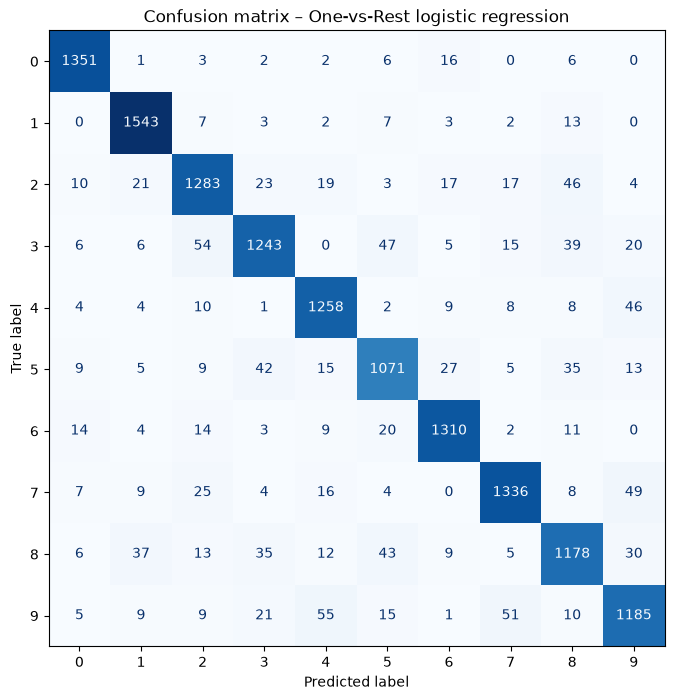

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix – One-vs-Rest logistic regression")
plt.show()

Typical mistakes for this model are pairs that look similar, e.g. 4 ↔ 9, 3 ↔ 5, 7 ↔ 9 or 2 ↔ 8. Let's look at some misclassified images:

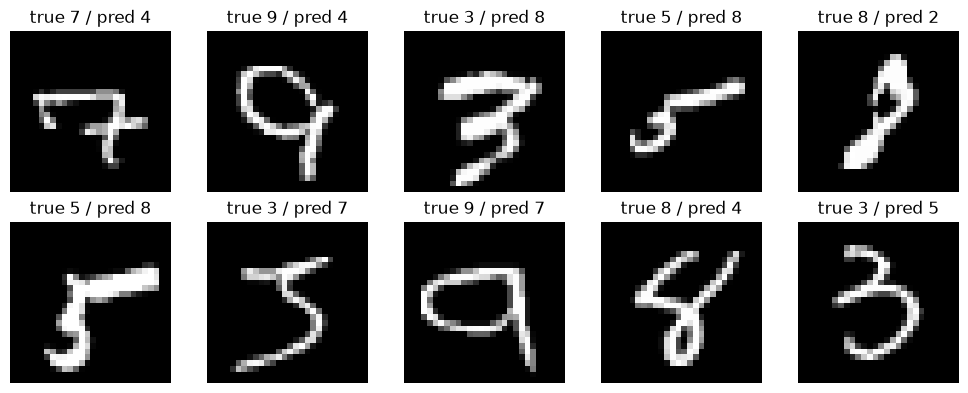

In [22]:
wrong = np.where(y_pred != y_test.values)[0]

plt.figure(figsize=(10, 4))
for n, idx in enumerate(wrong[:10]):
    plt.subplot(2, 5, n + 1)
    plt.imshow(X_test_scaled[idx].reshape(28, 28), cmap=plt.cm.gray)
    plt.title("true {} / pred {}".format(y_test.iloc[idx], y_pred[idx]))
    plt.axis("off")
plt.tight_layout()
plt.show()

#### 💡 Bonus: What did the models learn?
Each binary model has exactly one weight per pixel. If we reshape the 784 weights back to 28×28, we can see which pixels speak *for* (red) or *against* (blue) a digit – a kind of "template" for every digit:

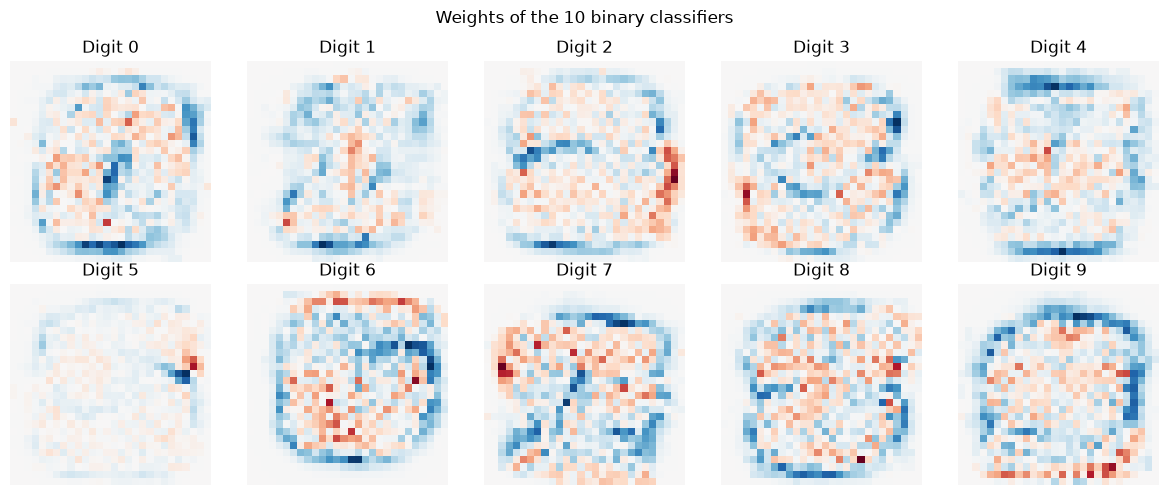

In [23]:
plt.figure(figsize=(12, 5))
for digit, model in enumerate(models):
    w = model.coef_.reshape(28, 28)
    limit = np.abs(w).max()
    plt.subplot(2, 5, digit + 1)
    plt.imshow(w, cmap="RdBu_r", vmin=-limit, vmax=limit)
    plt.title("Digit {}".format(digit))
    plt.axis("off")
plt.suptitle("Weights of the 10 binary classifiers")
plt.tight_layout()
plt.show()

#### 💡 Nifty alternative: sklearn's built-in `OneVsRestClassifier`
Steps 3–5 (loop, list of models, argmax over the probabilities) are exactly what `OneVsRestClassifier` does internally. With `n_jobs=-1` the 10 models are even trained in parallel on all CPU cores:

In [24]:
from sklearn.multiclass import OneVsRestClassifier

ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000), n_jobs=-1)
ovr.fit(X_train_scaled, y_train)

print("Accuracy OneVsRestClassifier: {:.2%}".format(ovr.score(X_test_scaled, y_test)))
print("Same predictions as our own implementation:", np.mean(ovr.predict(X_test_scaled) == y_pred))

Accuracy OneVsRestClassifier: 91.13%
Same predictions as our own implementation: 1.0


The result should be (practically) identical to our own implementation – a good check that our solution is correct. (`OneVsRestClassifier` also uses the argmax over the "positive" scores of the binary models.)

For comparison: the "real" multi-class version of logistic regression is **softmax / multinomial logistic regression**, which trains all 10 weight vectors *together*, so the probabilities do add up to 1. In sklearn this is the default behaviour of `LogisticRegression` when it gets more than two classes:

In [25]:
softmax_model = LogisticRegression(max_iter=1000)
softmax_model.fit(X_train_scaled, y_train)

print("Accuracy softmax (multinomial) logistic regression: {:.2%}".format(
    softmax_model.score(X_test_scaled, y_test)))

Accuracy softmax (multinomial) logistic regression: 91.73%


### Step 7: Tuning the regularization parameter `C` with `GridSearchCV`

Logistic regression in sklearn uses L2 regularization by default. The parameter `C` is the **inverse** regularization strength:
- **small `C`** (e.g. 0.1) → strong regularization → smaller weights, simpler model, risk of *underfitting*
- **large `C`** (e.g. 10) → weak regularization → model fits the training data more closely, risk of *overfitting*

`GridSearchCV` tries every value from the grid. With **5-fold cross-validation** the training data is split into 5 parts; the model is trained 5 times on 4 parts and validated on the remaining part. The `C` with the best average validation accuracy wins. The **test data is not touched** during this – it is only used once at the very end.

Three details in our setup:
1. **Pipeline:** We put the `MinMaxScaler` *into* a pipeline together with the model. Then the scaler is fitted anew inside each CV fold on the 4 training parts only, so there is no leakage into the validation fold. That's why we pass the *unscaled* `X_train` here.
2. **One-vs-Rest:** We wrap the logistic regression in `OneVsRestClassifier`, so we tune exactly the approach from Steps 3–5. The parameter is then addressed as `model__estimator__C` (pipeline step `model` → inside it the `estimator` → its `C`).
3. **Runtime:** 3 values × 5 folds × 10 binary models = 150 model fits. On the full 56,000 images this takes a long time, so we run the grid search on a random, stratified subset of 10,000 training images. The best `C` is then used to train the final model on all training data.

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# stratified subset to keep the runtime reasonable (same class distribution as y_train)
X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=10000,
                                      stratify=y_train, random_state=0)

pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("model", OneVsRestClassifier(LogisticRegression(max_iter=1000))),
])

param_grid = {"model__estimator__C": [0.1, 1.0, 10.0]}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)
grid.fit(X_sub, y_sub)

print("Best C:", grid.best_params_["model__estimator__C"])
print("Best mean CV accuracy: {:.2%}".format(grid.best_score_))

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best C: 0.1
Best mean CV accuracy: 90.74%


Overview of all tried values (mean and standard deviation over the 5 folds):

In [27]:
import pandas as pd

results = pd.DataFrame(grid.cv_results_)[["param_model__estimator__C", "mean_test_score", "std_test_score", "mean_fit_time"]]
results.columns = ["C", "mean CV accuracy", "std CV accuracy", "mean fit time [s]"]
results

,C,mean CV accuracy,std CV accuracy,mean fit time [s]
0,0.1,0.9074,0.004893,5.991906
1,1.0,0.9058,0.004389,9.978979
2,10.0,0.8918,0.005819,12.226546


Finally, we train the pipeline with the best `C` on the **complete** training data and evaluate it **once** on the test data:

In [28]:
best_C = grid.best_params_["model__estimator__C"]

final_model = Pipeline([
    ("scaler", MinMaxScaler()),
    ("model", OneVsRestClassifier(LogisticRegression(C=best_C, max_iter=1000), n_jobs=-1)),
])
final_model.fit(X_train, y_train)

print("Test accuracy with C = {}: {:.2%}".format(best_C, final_model.score(X_test, y_test)))
print("Test accuracy with C = 1.0 (Step 5): {:.2%}".format(accuracy_ovr))

Test accuracy with C = 0.1: 90.96%
Test accuracy with C = 1.0 (Step 5): 91.13%


### Conclusion

- Min-max normalization (fitted on the training data only) brings all pixels into $[0, 1]$ and makes the optimization stable.
- A single binary classifier ("9 or not 9") reaches a high accuracy, but because of the class imbalance this has to be compared with the ~90% baseline.
- Combining 10 binary classifiers with One-vs-Rest and taking the class with the highest probability gives roughly **90–92%** accuracy on the test data.
- Tuning `C` with 5-fold cross-validation typically changes the result only slightly – the limiting factor is that logistic regression is a **linear** model that treats every pixel independently. To get clearly above ~92%, we would need non-linear models (e.g. neural networks / CNNs, which reach > 99% on MNIST).